# Fraud Detection Model Fintech MLOps Stack

## Overview
This notebook builds a company-standard fraud detection model using supervised machine learning on the Kaggle Credit Card Fraud Detection dataset. The dataset contains 284,807 real transactions from European cardholders, of which only 492 (0.17%) are fraudulent making class imbalance the central challenge of this build.

The notebook follows a full end-to-end MLOps pipeline across 9 stages:

- **Stage 1 — Data Ingestion:** Load and verify the dataset using pandas
- **Stage 2 — Exploratory Data Analysis:** Understand the data distribution, class imbalance, and feature relationships before making any modelling decisions
- **Stage 3 — Preprocessing Pipeline:** Scale features, split data, and apply SMOTE to handle class imbalance without data leakage
- **Stage 4 — Feature Engineering:** Apply log transformation, cyclical time encoding, and interaction features inside a reproducible sklearn Pipeline
- **Stage 5 — Ensemble Model Training:** Build a stacking ensemble of XGBoost, Random Forest, and Logistic Regression with a Logistic Regression meta-learner
- **Stage 6 — Evaluation and Threshold Tuning:** Evaluate using AUC-ROC and F1-Score, then tune the classification threshold using predict_proba to optimise fraud detection performance
- **Stage 7 — Explainability:** Use SHAP to generate global feature importance and per-prediction audit trails
- **Stage 8 — Model Serialisation:** Serialise all pipeline artefacts using joblib for production deployment
- **Stage 9 — FastAPI Deployment:** Serve the model via a REST API with real-time fraud scoring, confidence tiers, and SHAP explanations in every response

## Dataset
- Source: Kaggle Credit Card Fraud Detection Dataset
- Transactions: 284,807
- Features: 30 numerical features (V1–V28 PCA components, Time, Amount)
- Target: Class (0 = Legitimate, 1 = Fraudulent)
- Fraud rate: 0.17%

## Tech Stack
- Language: Python 3.10+
- Data Processing: Pandas, NumPy, Scikit-learn
- Imbalance Handling: Imbalanced-learn (SMOTE)
- Modelling: XGBoost, Scikit-learn (StackingClassifier)
- Explainability: SHAP
- API Framework: FastAPI, Uvicorn
- Validation: Pydantic
- Persistence: Joblib



## Library Imports & Environment

#### We begin by importing all the core libraries needed across the full pipeline. These cover data loading and manipulation, visualisation, machine learning, class imbalance handling, model explainability, and serialisation. Importing everything upfront keeps the notebook clean and makes dependencies immediately visible to anyone reading the code.

In [1]:
# Core data libraries 
import pandas as pd
import numpy as np

# Visualisation libraries 
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings 
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline

print("All libraries imported successfully.")

All libraries imported successfully.


## Data Ingestion

#### We load the Kaggle Credit Card Fraud Detection dataset directly from our data/ folder using pandas. After loading we run four inspection checks shape, data types, statistical summary, and null count to confirm the dataset is complete and clean before any processing begins. Every decision made in later stages is grounded in what these checks reveal.

In [2]:
# Load the dataset 
df = pd.read_csv('../data/creditcard.csv')

# Check 1: Shape 
print("Shape:", df.shape)
print("-" * 40)

# Check 2: Data types and null counts 
print(df.info())
print("-" * 40)

# Check 3: Statistical summary 
print(df.describe())
print("-" * 40)

# Check 4: Explicit null check 
print("Null counts per column:")
print(df.isnull().sum())

Shape: (284807, 31)
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  

### Data Preview

#### We preview the first 5 rows to visually confirm the dataset loaded correctly and inspect what raw values look like across all 31 columns.

In [3]:
# Preview first 5 rows 
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


## Class Distribution Check

#### We check how many transactions are fraudulent versus legitimate. This is the most critical check in the entire EDA the result directly determines our resampling strategy. If the dataset is severely imbalanced, a naive model will simply predict "legitimate" for everything and still achieve high accuracy while catching zero fraud.

In [4]:
# Class distribution 
print("Class counts:")
print(df['Class'].value_counts())
print()
print("Class percentages:")
print(df['Class'].value_counts(normalize=True) * 100)

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentages:
Class
0   99.8273
1    0.1727
Name: proportion, dtype: float64


### Class Distribution Visualisation

#### We plot the class distribution as a bar chart to make the imbalance immediately visible. Numbers alone can be abstract, a visual makes the severity of the 578:1 ratio immediately obvious to any reader of this notebook.

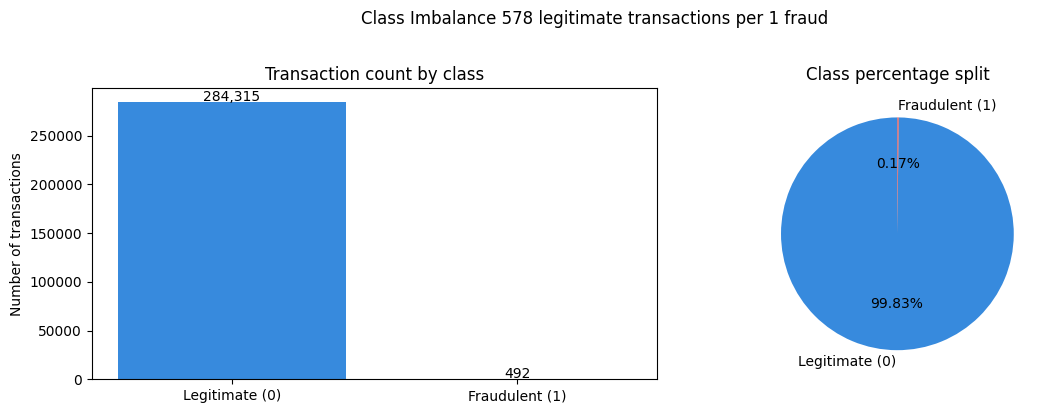

In [5]:
# Visualise class distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart — raw counts
class_counts = df['Class'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraudulent (1)'],
            class_counts.values,
            color=['#378ADD', '#E24B4A'],
            edgecolor='none')
axes[0].set_title('Transaction count by class')
axes[0].set_ylabel('Number of transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)

# Pie chart — percentage split
axes[1].pie(class_counts.values,
            labels=['Legitimate (0)', 'Fraudulent (1)'],
            autopct='%1.2f%%',
            colors=['#378ADD', '#E24B4A'],
            startangle=90)
axes[1].set_title('Class percentage split')

plt.suptitle('Class Imbalance 578 legitimate transactions per 1 fraud',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA)

#### EDA is our forensic investigation of the dataset before any modelling begins. Every preprocessing and feature engineering decision we make in later stages is grounded in what we discover here. We run five checks: Amount distribution, Time distribution, duplicate detection, outlier analysis, and a correlation heatmap. Each check answers a specific question about the data.

### EDA Check 1:  Transaction Amount Distribution

#### We analyse the Amount feature split by class to understand if fraudulent transactions have a distinct financial signature. This tells us whether Amount is a strong fraud signal and confirms why it needs scaling and log transformation before training.

Amount statistics by class:
            count     mean      std    min    25%     50%      75%        max
Class                                                                        
0     284315.0000  88.2910 250.1051 0.0000 5.6500 22.0000  77.0500 25691.1600
1        492.0000 122.2113 256.6833 0.0000 1.0000  9.2500 105.8900  2125.8700



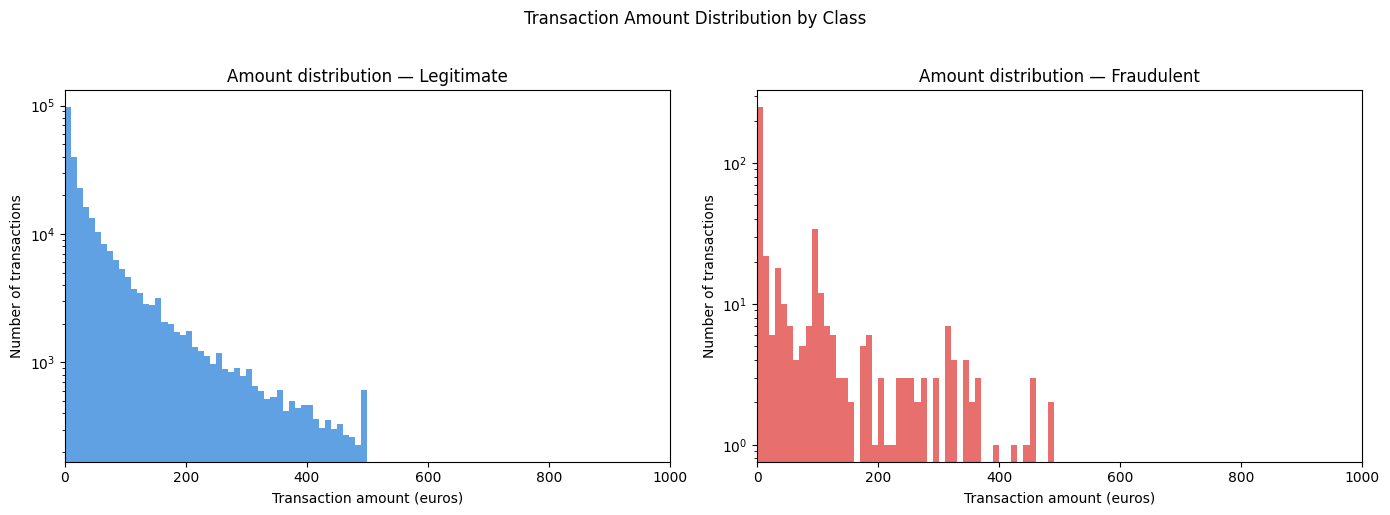

In [11]:
# Amount statistics split by class 
print("Amount statistics by class:")
print(df.groupby('Class')['Amount'].describe())
print()

# Amount distribution plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Legitimate transactions
axes[0].hist(df[df['Class'] == 0]['Amount'],
             range=(0, 500),
             bins=50,
             color='#378ADD',
             edgecolor='none',
             alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_title('Amount distribution — Legitimate')
axes[0].set_xlabel('Transaction amount (euros)')
axes[0].set_ylabel('Number of transactions')
axes[0].set_xlim(0, 1000)

# Fraudulent transactions
axes[1].hist(df[df['Class'] == 1]['Amount'],
             range=(0, 500),
             bins=50,
             color='#E24B4A',
             edgecolor='none',
             alpha=0.8)
axes[1].set_yscale('log')
axes[1].set_title('Amount distribution — Fraudulent')
axes[1].set_xlabel('Transaction amount (euros)')
axes[1].set_ylabel('Number of transactions')
axes[1].set_xlim(0, 1000)

plt.suptitle('Transaction Amount Distribution by Class', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### EDA Check 2: Transaction Time Distribution

#### We analyse the Time feature split by class to understand whether fraud follows a different temporal pattern from legitimate transactions. Time is recorded as seconds elapsed since the first transaction we examine whether fraudulent activity clusters at specific periods, which will inform our cyclical encoding in Stage 4.

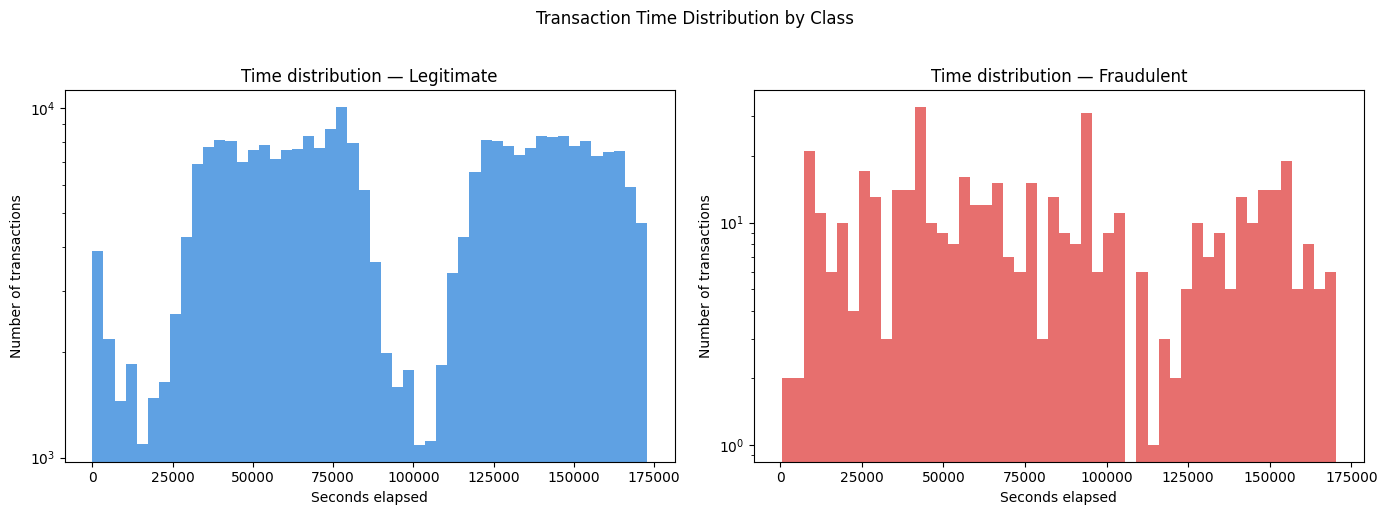

Time statistics by class:
            count       mean        std      min        25%        50%  \
Class                                                                    
0     284315.0000 94838.2023 47484.0158   0.0000 54230.0000 84711.0000   
1        492.0000 80746.8069 47835.3651 406.0000 41241.5000 75568.5000   

              75%         max  
Class                          
0     139333.0000 172792.0000  
1     128483.0000 170348.0000  


In [ ]:
# Time distribution split by class 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Legitimate transactions
axes[0].hist(df[df['Class'] == 0]['Time'],
             bins=50,
             color='#378ADD',
             edgecolor='none',
             alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_title('Time distribution — Legitimate')
axes[0].set_xlabel('Seconds elapsed')
axes[0].set_ylabel('Number of transactions')

# Fraudulent transactions
axes[1].hist(df[df['Class'] == 1]['Time'],
             bins=50,
             color='#E24B4A',
             edgecolor='none',
             alpha=0.8)
axes[1].set_yscale('log')
axes[1].set_title('Time distribution — Fraudulent')
axes[1].set_xlabel('Seconds elapsed')
axes[1].set_ylabel('Number of transactions')

plt.suptitle('Transaction Time Distribution by Class', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

#  Time statistics split by class 
print("Time statistics by class:")
print(df.groupby('Class')['Time'].describe())

### EDA Check 3: Duplicate Detection

#### We check for duplicate rows in the dataset. Duplicate transactions can occur from API retries, system errors, or manual data uploads. If left in the training data, duplicates bias the model toward patterns it has seen multiple times and inflate evaluation metrics artificially.

In [13]:
#  Duplicate detection 
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")
print()

if duplicate_count > 0:
    print(f"Removing {duplicate_count} duplicate rows...")
    df = df.drop_duplicates()
    print(f"Dataset shape after removing duplicates: {df.shape}")
else:
    print("No duplicates found. Dataset is clean.")

print()
print(f"Final dataset shape: {df.shape}")

Total duplicate rows: 1081

Removing 1081 duplicate rows...
Dataset shape after removing duplicates: (283726, 31)

Final dataset shape: (283726, 31)


### Duplicate Removal Class Impact Check

#### We verify how the duplicate removal affected the class distribution to ensure our fraud count and imbalance ratio are still valid after cleaning.

In [14]:
# Verify class distribution after duplicate removal 
print("Class distribution after duplicate removal:")
print(df['Class'].value_counts())
print()
print("Class percentages after duplicate removal:")
print(df['Class'].value_counts(normalize=True) * 100)

Class distribution after duplicate removal:
Class
0    283253
1       473
Name: count, dtype: int64

Class percentages after duplicate removal:
Class
0   99.8333
1    0.1667
Name: proportion, dtype: float64


### EDA Check 4: Outlier Detection

#### We identify extreme outliers in the Amount feature using the Interquartile Range (IQR) method. Outliers in transaction data can represent either genuine fraud signals or data errors. We analyse them before deciding how to treat them in preprocessing.

In [15]:
# IQR outlier detection on Amount 
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[(df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)]

print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print()
print(f"Total outliers detected: {len(outliers)}")
print()
print("Outlier class breakdown:")
print(outliers['Class'].value_counts())
print()
print(f"Outlier fraud rate: {outliers['Class'].mean() * 100:.4f}%")
print(f"Overall fraud rate: {df['Class'].mean() * 100:.4f}%")

Q1 (25th percentile): 5.60
Q3 (75th percentile): 77.51
IQR: 71.91
Lower bound: -102.27
Upper bound: 185.38

Total outliers detected: 31685

Outlier class breakdown:
Class
0    31598
1       87
Name: count, dtype: int64

Outlier fraud rate: 0.2746%
Overall fraud rate: 0.1667%


### Outlier Treatment Decision

#### The IQR analysis identified 31,685 transactions above €185.38 as statistical outliers. However the fraud rate within this outlier group is 0.2746%, significantly higher than the overall fraud rate of 0.1667%. This confirms these extreme amounts are genuine fraud signals, not data errors.

#### Decision: Outliers are retained. We apply log transformation (np.log1p) to the Amount feature in Stage 4 to compress the scale without losing any fraud signal. Removing or capping these values would make the model blind to high-value fraud patterns.

### EDA Check 5: Correlation Heatmap

#### We compute the correlation between every feature and the Class target to identify which V components are the strongest direct predictors of fraud. Features with high positive or negative correlation with Class will be the most important inputs to our ensemble model, which SHAP will later confirm.

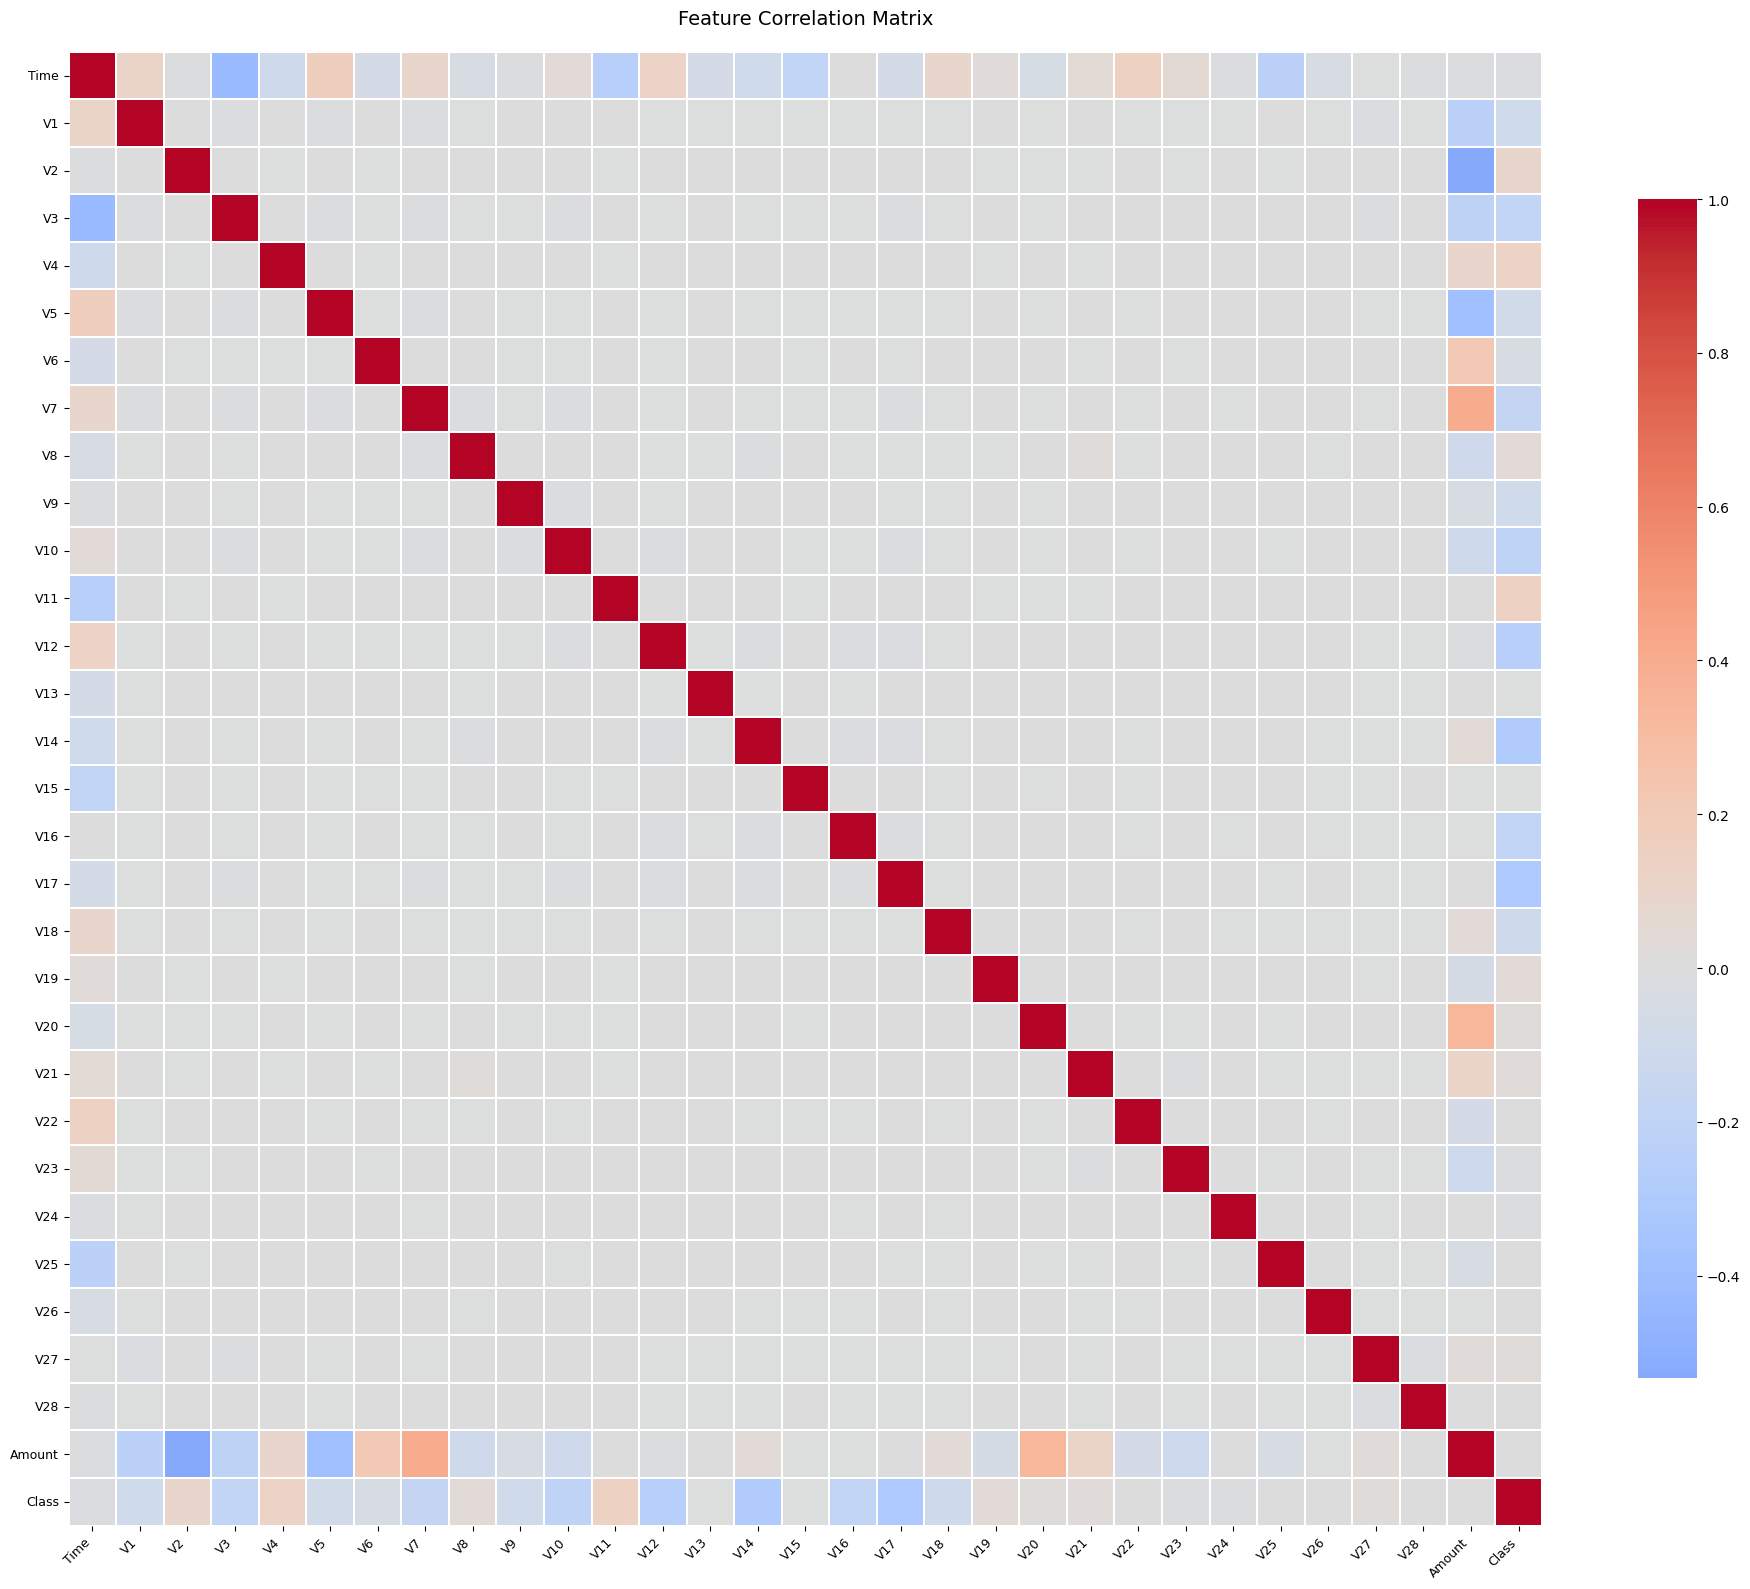

Feature correlation with Class target (sorted):
V17      -0.3135
V14      -0.2934
V12      -0.2507
V10      -0.2070
V16      -0.1872
V3       -0.1823
V7       -0.1723
V18      -0.1053
V1       -0.0945
V9       -0.0940
V5       -0.0878
V6       -0.0439
Time     -0.0124
V24      -0.0072
V23      -0.0063
V13      -0.0039
V15      -0.0033
V25       0.0032
V26       0.0043
V22       0.0049
Amount    0.0058
V28       0.0097
V20       0.0215
V27       0.0219
V21       0.0264
V8        0.0331
V19       0.0336
V2        0.0846
V4        0.1293
V11       0.1491


In [16]:
# Correlation heatmap 
plt.figure(figsize=(20, 16))

correlation_matrix = df.corr()

sns.heatmap(correlation_matrix,
            cmap='coolwarm',
            center=0,
            annot=False,
            linewidths=0.3,
            square=True,
            cbar_kws={'shrink': 0.8})

plt.title('Feature Correlation Matrix', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

#  Correlation with Class target specifically 
print("Feature correlation with Class target (sorted):")
class_corr = correlation_matrix['Class'].drop('Class').sort_values()
print(class_corr.to_string())